In [1]:
# ===============================
# Core Python Libraries
# ===============================
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from collections import Counter
from scipy.special import expit  # sigmoid

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ===============================
# NLP: NLTK & Gensim
# ===============================
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams

# ===============================
# Scikit-learn: Preprocessing, Models, Metrics
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ===============================
# TensorFlow / Keras
# ===============================
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Input, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ===============================
# Transformers (Hugging Face)
# ===============================
from transformers import (
    AutoTokenizer, AutoModel,
    RobertaTokenizer, RobertaModel,
    BertTokenizer, BertForSequenceClassification,
    XLNetTokenizer, XLNetForSequenceClassification
)
import torch
from torch.optim import AdamW

# ===============================
# Custom Modules
# ===============================
from metrics_calculator import MetricsCalculator
from graphs import GraphPlotter
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
import nltk

# Tokenizer
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Stopwords
nltk.download('stopwords', quiet=True)

# WordNet for lemmatizer
nltk.download('wordnet', quiet=True)

#  POS tagging for better lemmatization
nltk.download('averaged_perceptron_tagger', quiet=True)

nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\PRACHETANA
[nltk_data]     GODISHALA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [3]:
def upload_dataset(file_path):
    """Load the dataset from a CSV file"""
    df = pd.read_csv(file_path,)
    return df

In [4]:
path=r"Dataset/gics-map-2023.csv"

In [5]:
df= upload_dataset(path)
df

,SectorId,Sector,IndustryGroupId,IndustryGroup,IndustryId,Industry,SubIndustryId,SubIndustry,SubIndustryDescription
0,10,Energy,1010,Energy,101010,Energy Equipment & Services,10101010,Oil & Gas Drilling,Drilling contractors or owners of drilling rig...
1,10,Energy,1010,Energy,101010,Energy Equipment & Services,10101020,Oil & Gas Equipment & Services,"Manufacturers of equipment, including drilling..."
2,10,Energy,1010,Energy,101020,"Oil, Gas & Consumable Fuels",10102010,Integrated Oil & Gas,Integrated oil companies engaged in the explor...
3,10,Energy,1010,Energy,101020,"Oil, Gas & Consumable Fuels",10102020,Oil & Gas Exploration & Production,Companies engaged in the exploration and produ...
4,10,Energy,1010,Energy,101020,"Oil, Gas & Consumable Fuels",10102030,Oil & Gas Refining & Marketing,Companies engaged in the refining and marketin...
...,...,...,...,...,...,...,...,...,...
158,60,Real Estate,6010,Equity Real Estate Investment Trusts (REITs),601080,Specialized REITs,60108050,Data Center REITs,Companies or Trusts engaged in the acquisition...
159,60,Real Estate,6020,Real Estate Management & Development,602010,Real Estate Management & Development,60201010,Diversified Real Estate Activities,Companies engaged in a diverse spectrum of rea...
160,60,Real Estate,6020,Real Estate Management & Development,602010,Real Estate Management & Development,60201020,Real Estate Operating Companies,Companies engaged in operating real estate pro...
161,60,Real Estate,6020,Real Estate Management & Development,602010,Real Estate Management & Development,60201030,Real Estate Development,Companies that develop real estate and sell th...


In [6]:
def preprocess_data(df, save_path=None, target_cols=None):

    global label_encoders
    label_encoders = {}  # dictionary to hold encoders for each target column

    if save_path and os.path.exists(save_path):
        print(f"Loading existing preprocessed file: {save_path}")
        df = pd.read_csv(save_path)
    else:
        print("Preprocessing data" + (f" and saving to: {save_path}" if save_path else " (no saving)"))
        lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words('english'))

        def clean_text(text):
            text = str(text).lower()
            tokens = word_tokenize(text)
            tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalnum() and t not in stop_words]
            return ' '.join(tokens)

        # Separate target columns
        target_df = None
        if target_cols:
            existing_targets = [col for col in target_cols if col in df.columns]
            target_df = df[existing_targets].copy()
            df = df.drop(columns=existing_targets)

        # Process text columns
        text_columns = df.select_dtypes(include='object').columns
        for col in text_columns:
            df[f'processed_{col}'] = df[col].apply(clean_text)

        # Drop original text columns
        df.drop(columns=text_columns, inplace=True)

        # Reattach target columns
        if target_df is not None:
            for col in target_df.columns:
                df[col] = target_df[col]

        # Save only if path is specified
        if save_path:
            df.to_csv(save_path, index=False)

    # Select processed and numerical columns
    processed_text_cols = [col for col in df.columns if col.startswith('processed_')]
    non_text_cols = [col for col in df.columns if col not in processed_text_cols + (target_cols if target_cols else [])]

    # Join processed text columns into one string
    X_text = df[processed_text_cols].astype(str).agg(' '.join, axis=1)

    # Combine with numerical columns if any
    X_numeric = df[non_text_cols].values if non_text_cols else None
    if X_numeric is not None and len(X_numeric) > 0:
        X = [f"{text} {' '.join(map(str, numeric))}" for text, numeric in zip(X_text, X_numeric)]
    else:
        X = X_text.tolist()

    # Encode multiple target columns
    Y_dict = {}
    if target_cols:
        for col in target_cols:
            if col in df.columns:
                le = LabelEncoder()
                Y_dict[col] = le.fit_transform(df[col])
                label_encoders[col] = le

    return X, Y_dict

In [7]:
X, Y_dict = preprocess_data(df, save_path="model/cleaned_data.csv", target_cols=["IndustryGroup"])

Loading existing preprocessed file: model/cleaned_data.csv


In [8]:
labels_vars = {}  # dictionary to hold the labels
label_encoders_original = label_encoders
for i, (col, le) in enumerate(label_encoders.items(), start=1):
    var_name = f"labels{i}"
    labels_vars[var_name] = list(le.classes_)

for idx, class_name in enumerate(labels_vars["labels1"]):
    print(f"labels{idx}: {class_name}")

labels1 = labels_vars.get("labels1")

print("labels1:", labels1)


metrics_calculator_lb1 = MetricsCalculator(labels1)


labels0: Automobiles & Components
labels1: Banks
labels2: Capital Goods
labels3: Commercial  & Professional Services
labels4: Consumer Discretionary Distribution & Retail 
labels5: Consumer Durables & Apparel
labels6: Consumer Services
labels7: Consumer Staples Distribution & Retail
labels8: Energy
labels9: Equity Real Estate Investment Trusts (REITs)
labels10: Financial Services 
labels11: Food, Beverage & Tobacco
labels12: Health Care Equipment & Services
labels13: Household & Personal Products
labels14: Insurance
labels15: Materials
labels16: Media & Entertainment
labels17: Pharmaceuticals, Biotechnology & Life Sciences
labels18: Real Estate Management & Development
labels19: Semiconductors & Semiconductor Equipment
labels20: Software & Services
labels21: Technology Hardware & Equipment
labels22: Telecommunication Services
labels23: Transportation
labels24: Utilities
labels1: ['Automobiles & Components', 'Banks', 'Capital Goods', 'Commercial  & Professional Services', 'Consumer Disc

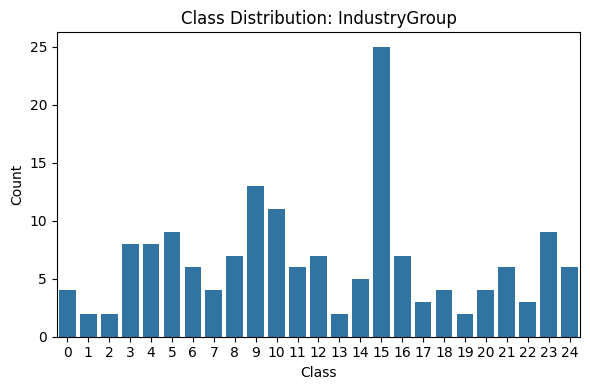

In [9]:
def plot_target_distributions(Y_dict):
    """
    Create count plots for each target column in Y_dict.
    
    Parameters:
        Y_dict (dict): Dictionary where keys are target column names and values are encoded label arrays.
    """
    # Convert to DataFrame for easy plotting
    y_df = pd.DataFrame(Y_dict)

    # Plot each column
    for col in y_df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=y_df[col])
        plt.title(f'Class Distribution: {col}')
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
plot_target_distributions(Y_dict)


In [10]:
def eda_nlp_analysis(X_text, num_words=100, top_n_words=20):
    """
    Perform NLP EDA:
        1. WordCloud
        2. Top N words
        3. Document length histogram
        4. POS tag frequency
        5. Bigram frequency

    Parameters:
        X_text (list of str): Input preprocessed text data.
        num_words (int): Number of words to show in word cloud.
        top_n_words (int): Number of top frequent words to plot.
    """
    print("Generating NLP EDA Visualizations...")

    # Flatten all tokens from all texts
    all_tokens = [word for doc in X_text for word in word_tokenize(doc)]

    # --- 1. WordCloud ---
    word_freq = Counter(all_tokens)
    wc = WordCloud(width=800, height=400, max_words=num_words, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top {num_words} Words - WordCloud")
    plt.show()

    # --- 2. Top-N Frequent Words ---
    common_words = word_freq.most_common(top_n_words)
    words, counts = zip(*common_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title(f"Top {top_n_words} Most Frequent Words")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

    # --- 3. Document Length Histogram ---
    doc_lengths = [len(word_tokenize(doc)) for doc in X_text]
    plt.figure(figsize=(10, 5))
    sns.histplot(doc_lengths, bins=20, kde=True, color='teal')
    plt.title("Distribution of Document Lengths (in words)")
    plt.xlabel("Number of Words per Document")
    plt.ylabel("Frequency")
    plt.show()

    # --- 4. POS Tag Frequency ---
    all_pos = [tag for _, tag in pos_tag(all_tokens)]
    pos_counts = Counter(all_pos).most_common()
    pos_tags, pos_freqs = zip(*pos_counts)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")
    plt.title("Part of Speech (POS) Tag Frequency")
    plt.xlabel("POS Tag")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

    # --- 5. Bigram Frequency Plot ---
    bigrams = list(ngrams(all_tokens, 2))
    bigram_freq = Counter(bigrams).most_common(top_n_words)
    bigram_labels = [' '.join(b) for b, _ in bigram_freq]
    bigram_counts = [count for _, count in bigram_freq]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")
    plt.title(f"Top {top_n_words} Bigrams")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.show()


Generating NLP EDA Visualizations...


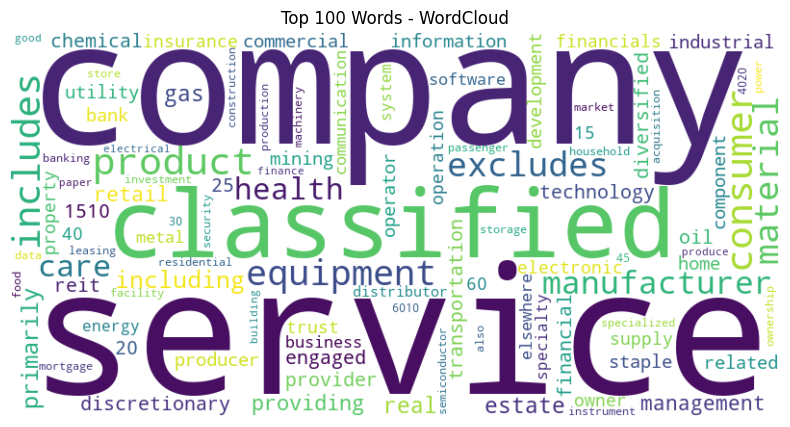

C:\Users\PRACHETANA GODISHALA\AppData\Local\Temp\ipykernel_22832\1063056502.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


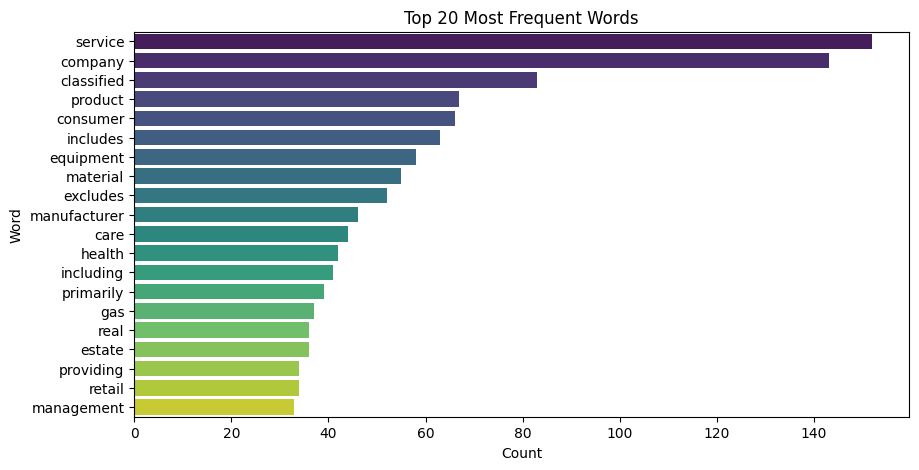

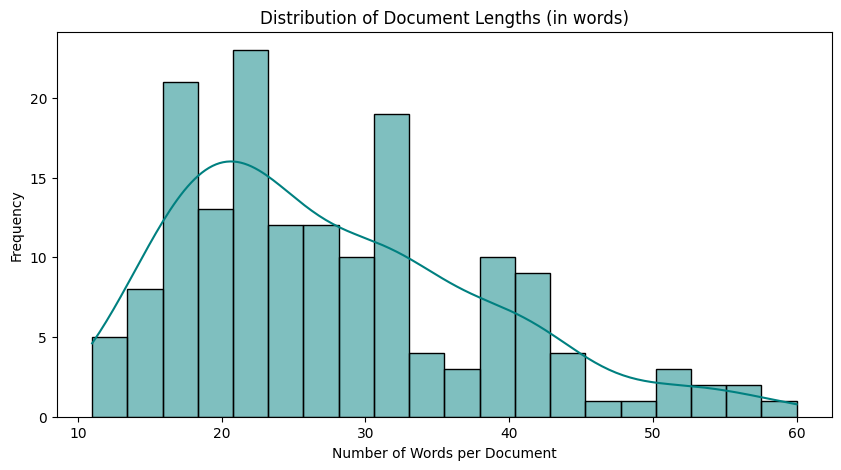

C:\Users\PRACHETANA GODISHALA\AppData\Local\Temp\ipykernel_22832\1063056502.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")


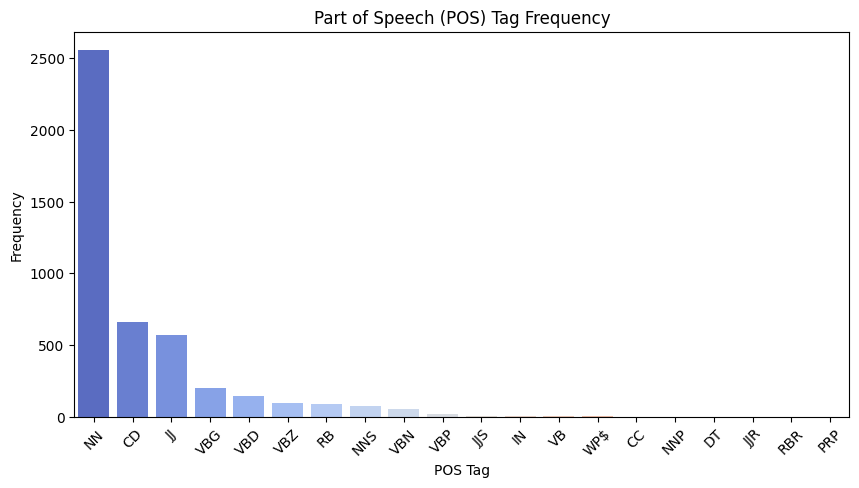

C:\Users\PRACHETANA GODISHALA\AppData\Local\Temp\ipykernel_22832\1063056502.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")


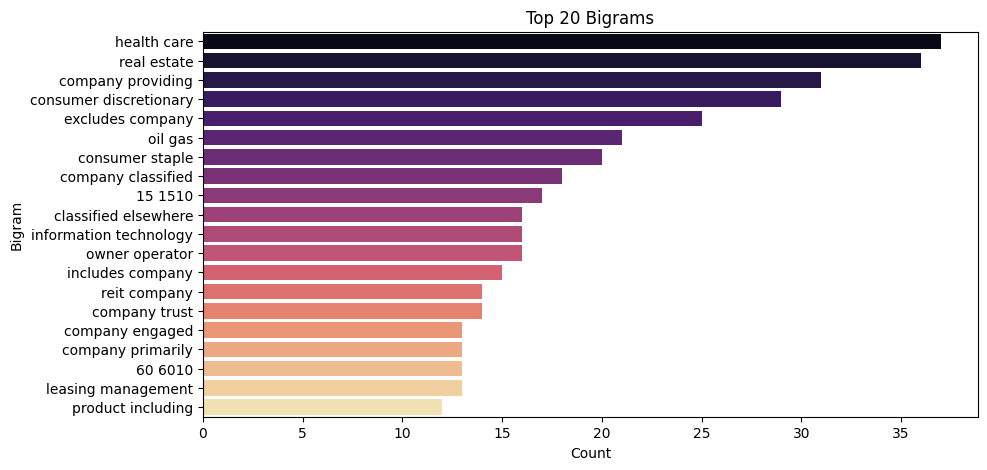

In [11]:
eda_nlp_analysis(X_text=X, num_words=100, top_n_words=20)

In [12]:
from tqdm import tqdm
def roberta_feature_extraction(texts, model_name='roberta-base', batch_size=32, pooling='mean'):
    """Extract RoBERTa features from texts with tqdm progress bar."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting RoBERTa embeddings"):
        batch_texts = texts[i:i+batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt')

        with torch.no_grad():
            model_output = model(**encoded_input)

        token_embeddings = model_output.last_hidden_state  # [batch_size, seq_len, hidden_dim]
        attention_mask = encoded_input['attention_mask']
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

        if pooling == 'mean':
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
            sum_mask = input_mask_expanded.sum(dim=1)
            embeddings = sum_embeddings / sum_mask
        elif pooling == 'cls':
            embeddings = token_embeddings[:, 0, :]  # CLS token
        else:
            raise ValueError("Pooling must be 'mean' or 'cls'")

        all_embeddings.append(embeddings.cpu().numpy())

    X = np.vstack(all_embeddings)
    return X, model


def feature_extraction(X_text, method='RoBERTa_word_embeddings', model_dir='model', is_train=True):
    x_file = os.path.join(model_dir, f'X_{method}.pkl')

    print(f"[INFO] Feature extraction method: {method}, Train mode: {is_train}")
    model_name = 'distilroberta-base'  # Lightweight alternatives: 'roberta-small', 'distilroberta-base'

    if is_train:
        if os.path.exists(x_file):
            print(f"[INFO] Loading cached RoBERTa features from {x_file}")
            X = joblib.load(x_file)
        else:
            print("[INFO] Computing RoBERTa features...")
            X, model = roberta_feature_extraction(X_text, model_name=model_name, pooling='mean')
            os.makedirs(model_dir, exist_ok=True)
            joblib.dump(X, x_file)
    else:
        print("[INFO] Performing RoBERTa feature extraction for testing...")
        X, model = roberta_feature_extraction(X_text, model_name=model_name, pooling='mean')

    return X

In [13]:
features = feature_extraction(X, method='Distil RoBERT with Word Embeddings',is_train=True)

[INFO] Feature extraction method: Distil RoBERT with Word Embeddings, Train mode: True
[INFO] Loading cached RoBERTa features from model\X_Distil RoBERT with Word Embeddings.pkl



🔹 Processing 'IndustryGroup' ...
Before balance: features.shape = (163, 768), labels.shape = (163,)


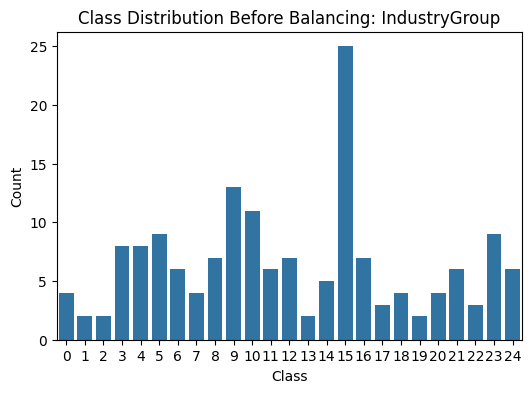

Class distribution before: {0: 4, 1: 2, 2: 2, 3: 8, 4: 8, 5: 9, 6: 6, 7: 4, 8: 7, 9: 13, 10: 11, 11: 6, 12: 7, 13: 2, 14: 5, 15: 25, 16: 7, 17: 3, 18: 4, 19: 2, 20: 4, 21: 6, 22: 3, 23: 9, 24: 6}
After balance:  features1.shape = (625, 768), Y1.shape = (625,)


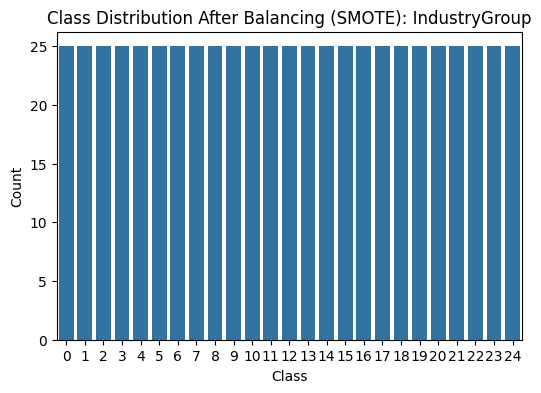

Class distribution after: {0: 25, 1: 25, 2: 25, 3: 25, 4: 25, 5: 25, 6: 25, 7: 25, 8: 25, 9: 25, 10: 25, 11: 25, 12: 25, 13: 25, 14: 25, 15: 25, 16: 25, 17: 25, 18: 25, 19: 25, 20: 25, 21: 25, 22: 25, 23: 25, 24: 25}


In [14]:
from imblearn.over_sampling import SMOTE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

features_resampled = {}
labels_resampled = {}

for i, (key, y) in enumerate(Y_dict.items(), start=1):
    print(f"\n🔹 Processing '{key}' ...")
    print(f"Before balance: features.shape = {features.shape}, labels.shape = {y.shape}")

    # Plot class distribution before
    plt.figure(figsize=(6,4))
    sns.countplot(x=y)
    plt.title(f"Class Distribution Before Balancing: {key}")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    # Count class distribution
    unique, counts = np.unique(y, return_counts=True)
    print(f"Class distribution before: {dict(zip(unique, counts))}")

    min_class_count = counts.min()

    # Adjust k_neighbors dynamically so it won’t break
    k_neighbors = min(5, max(1, min_class_count - 1))

    # Initialize SMOTE (balance ALL classes equally)
    smote = SMOTE(
        random_state=42,
        k_neighbors=k_neighbors,
        sampling_strategy="auto"   # <-- all classes balanced to majority
    )

    # Apply SMOTE
    X_resampled, y_resampled = smote.fit_resample(features, y)

    features_resampled[f'features{i}'] = X_resampled
    labels_resampled[f'Y{i}'] = y_resampled

    print(f"After balance:  features{i}.shape = {X_resampled.shape}, Y{i}.shape = {y_resampled.shape}")

    # Plot class distribution after
    plt.figure(figsize=(6,4))
    sns.countplot(x=y_resampled)
    plt.title(f"Class Distribution After Balancing (SMOTE): {key}")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    # Print counts
    unique_res, counts_res = np.unique(y_resampled, return_counts=True)
    print(f"Class distribution after: {dict(zip(unique_res, counts_res))}")

# Wrap into dictionaries for downstream ML
features_dict = {
    'IndustryGroup': features_resampled['features1']
}

labels_dict = {
    'IndustryGroup': labels_resampled['Y1']
}


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

def train_single_ml_model(Algorithm_prefix, features_dict, Y_dict, algorithm):

    ml_models = {}

    # Mapping of algorithm names to model classes
    model_mapping = {
        "LR": LogisticRegression,
        "RFC": RandomForestClassifier,
        "SVC": SVC
    }

    if algorithm not in model_mapping:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    for target_name, y_encoded in Y_dict.items():
        X = features_dict[target_name]
        model_instance = model_mapping[algorithm]()
        model_path = f"model/{Algorithm_prefix}_{target_name}_{algorithm}_model.pkl"
        algo_name = f"{Algorithm_prefix} {algorithm} [{target_name}]"

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
        )

        if os.path.exists(model_path):
            print(f"Loading existing {algorithm} model for {target_name}...")
            mdl = joblib.load(model_path)
        else:
            print(f"Training {algorithm} for target: {target_name}...")
            mdl = model_instance
            mdl.fit(X_train, y_train)
            joblib.dump(mdl, model_path)

        y_pred = mdl.predict(X_test)
        try:
            y_score = mdl.predict_proba(X_test)
        except AttributeError:
            y_score = None

        # Metrics calculation
        if target_name == "IndustryGroup":
            metrics_calculator_lb1.calculate_metrics(algo_name, y_pred, y_test, y_score)
        else:
            metrics_calculator_lb1.calculate_metrics(algo_name, y_pred, y_test, y_score)

        ml_models[f"{target_name}_{algorithm}"] = mdl

    return ml_models

Loading existing LR model for IndustryGroup...
Distil RoBERT-WE LR [IndustryGroup] Accuracy  : 100.00
Distil RoBERT-WE LR [IndustryGroup] Precision : 100.00
Distil RoBERT-WE LR [IndustryGroup] Recall    : 100.00
Distil RoBERT-WE LR [IndustryGroup] FScore    : 100.00
Distil RoBERT-WE LR [IndustryGroup] Classification Report
Distil RoBERT-WE LR [IndustryGroup]
                                                precision    recall  f1-score   support

                      Automobiles & Components       1.00      1.00      1.00         5
                                         Banks       1.00      1.00      1.00         5
                                 Capital Goods       1.00      1.00      1.00         5
           Commercial  & Professional Services       1.00      1.00      1.00         5
 Consumer Discretionary Distribution & Retail        1.00      1.00      1.00         5
                   Consumer Durables & Apparel       1.00      1.00      1.00         5
                      

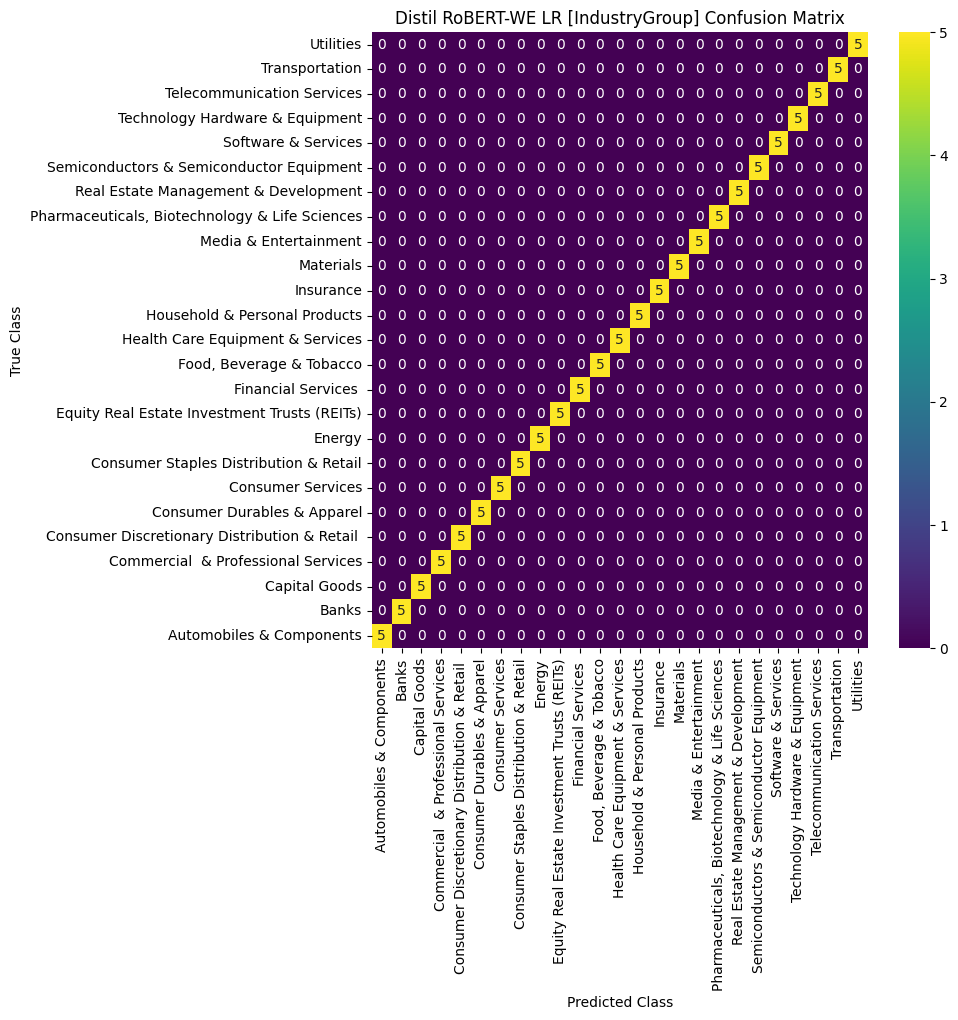

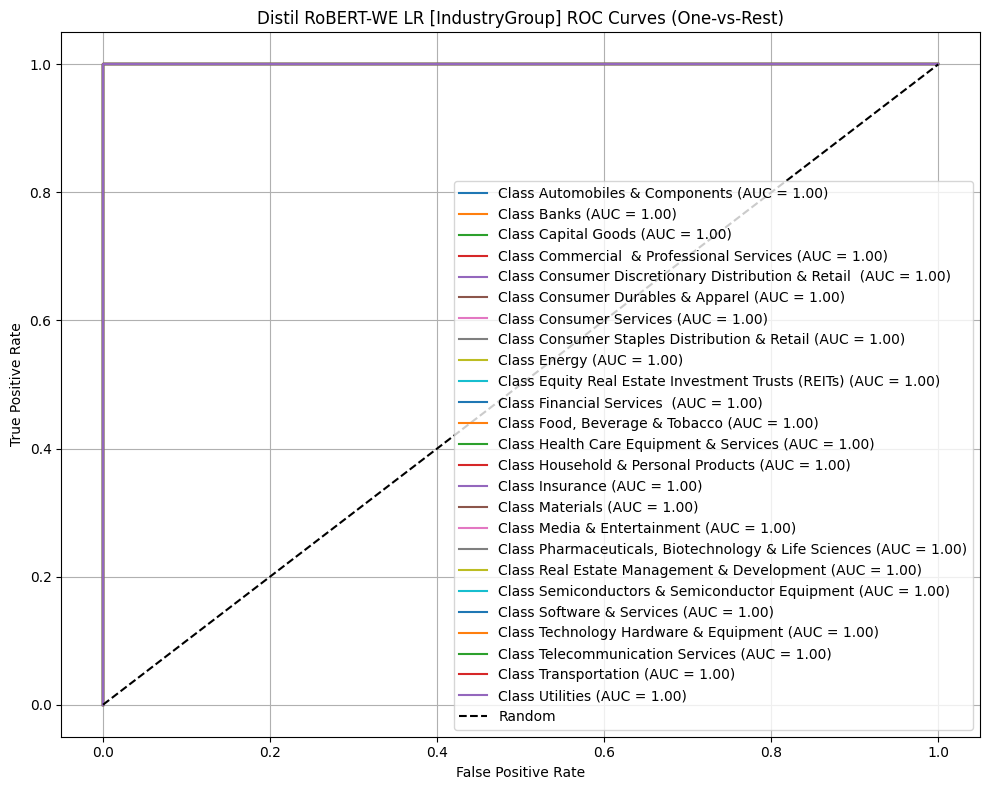

In [16]:
import warnings

# Disable all warnings
warnings.filterwarnings("ignore")

# Train the model (no warnings will be shown)
models = train_single_ml_model("Distil RoBERT-WE", features_dict, labels_dict, "LR")

Loading existing RFC model for IndustryGroup...
Distil RoBERT-WE RFC [IndustryGroup] Accuracy  : 99.20
Distil RoBERT-WE RFC [IndustryGroup] Precision : 99.33
Distil RoBERT-WE RFC [IndustryGroup] Recall    : 99.20
Distil RoBERT-WE RFC [IndustryGroup] FScore    : 99.19
Distil RoBERT-WE RFC [IndustryGroup] Classification Report
Distil RoBERT-WE RFC [IndustryGroup]
                                                precision    recall  f1-score   support

                      Automobiles & Components       1.00      1.00      1.00         5
                                         Banks       1.00      1.00      1.00         5
                                 Capital Goods       1.00      1.00      1.00         5
           Commercial  & Professional Services       1.00      1.00      1.00         5
 Consumer Discretionary Distribution & Retail        1.00      0.80      0.89         5
                   Consumer Durables & Apparel       1.00      1.00      1.00         5
                   

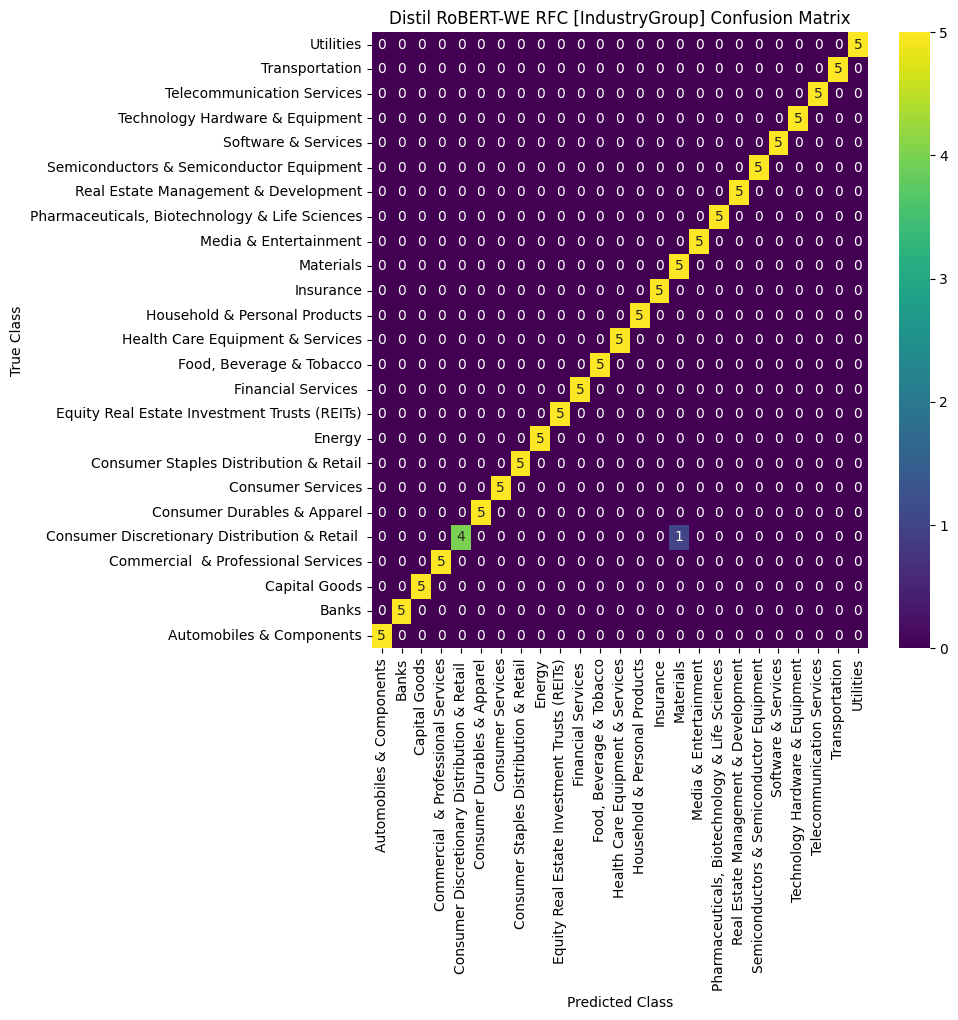

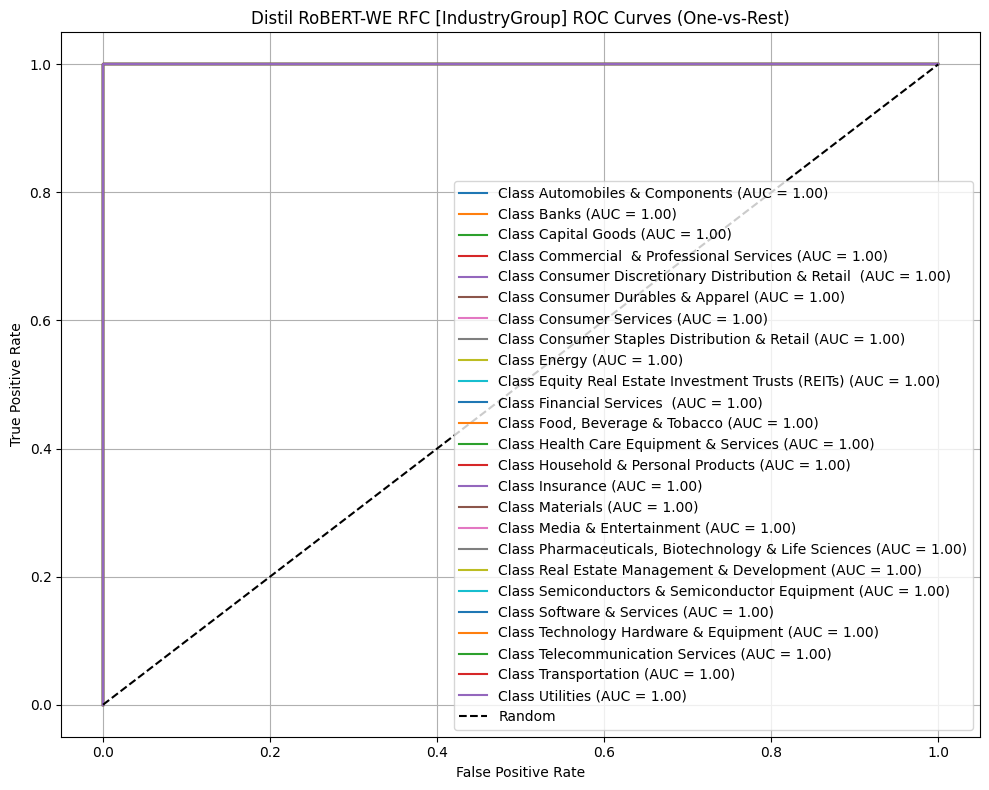

In [17]:
models = train_single_ml_model("Distil RoBERT-WE", features_dict, labels_dict, "RFC")

Loading existing SVC model for IndustryGroup...
Distil RoBERT-WE SVC [IndustryGroup] Accuracy  : 94.40
Distil RoBERT-WE SVC [IndustryGroup] Precision : 95.71
Distil RoBERT-WE SVC [IndustryGroup] Recall    : 94.40
Distil RoBERT-WE SVC [IndustryGroup] FScore    : 93.97
Distil RoBERT-WE SVC [IndustryGroup] Classification Report
Distil RoBERT-WE SVC [IndustryGroup]
                                                precision    recall  f1-score   support

                      Automobiles & Components       0.83      1.00      0.91         5
                                         Banks       1.00      1.00      1.00         5
                                 Capital Goods       0.71      1.00      0.83         5
           Commercial  & Professional Services       0.83      1.00      0.91         5
 Consumer Discretionary Distribution & Retail        1.00      0.80      0.89         5
                   Consumer Durables & Apparel       1.00      1.00      1.00         5
                   

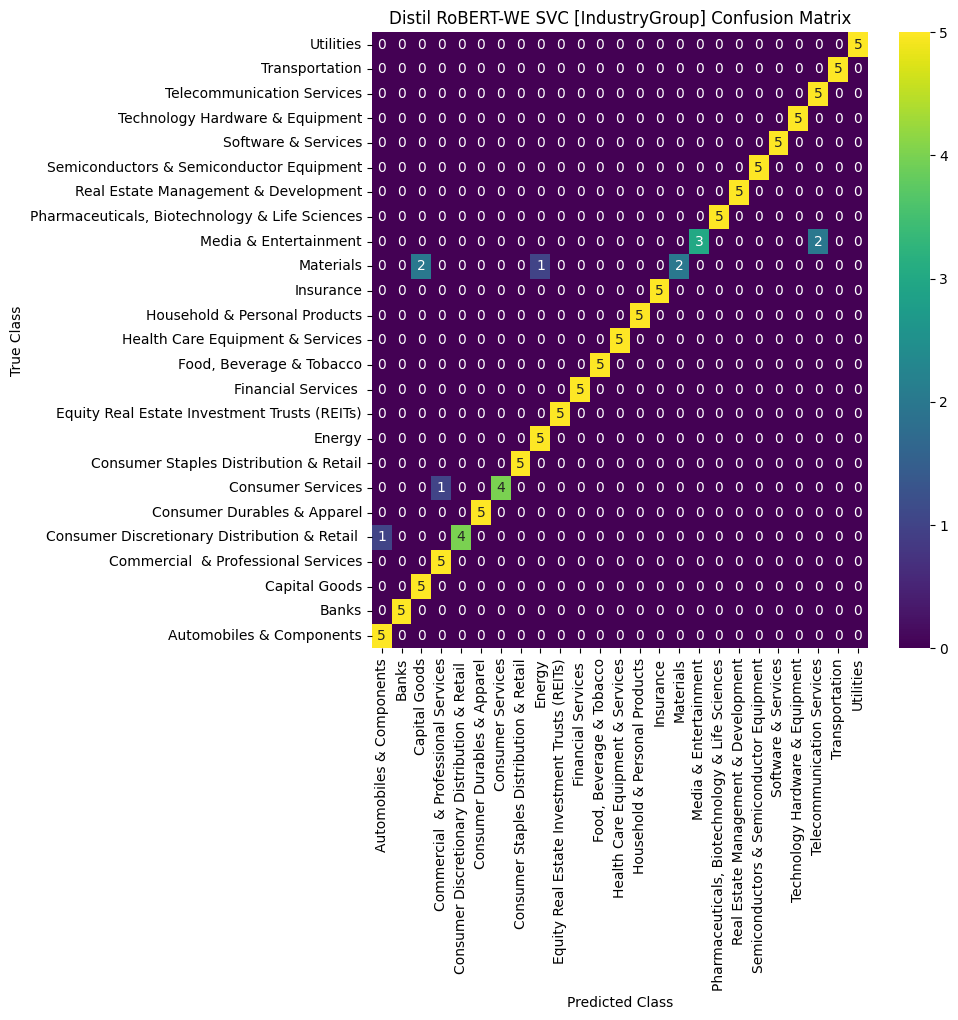

[WARNING] y_score is None. Cannot plot ROC.


In [18]:
models = train_single_ml_model("Distil RoBERT-WE", features_dict, labels_dict, "SVC")

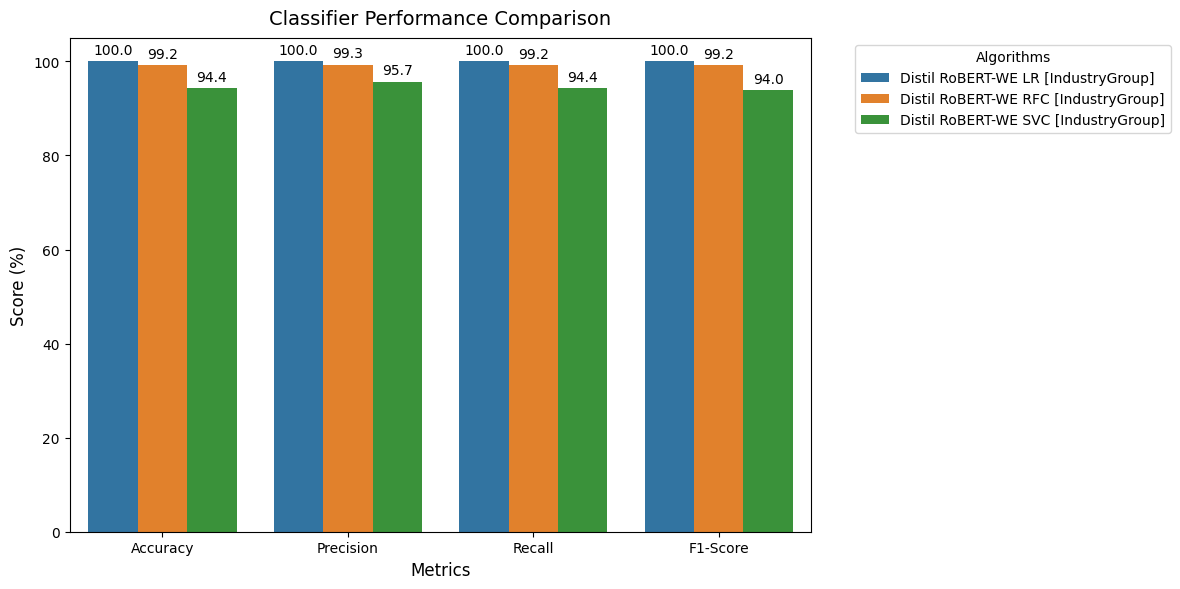

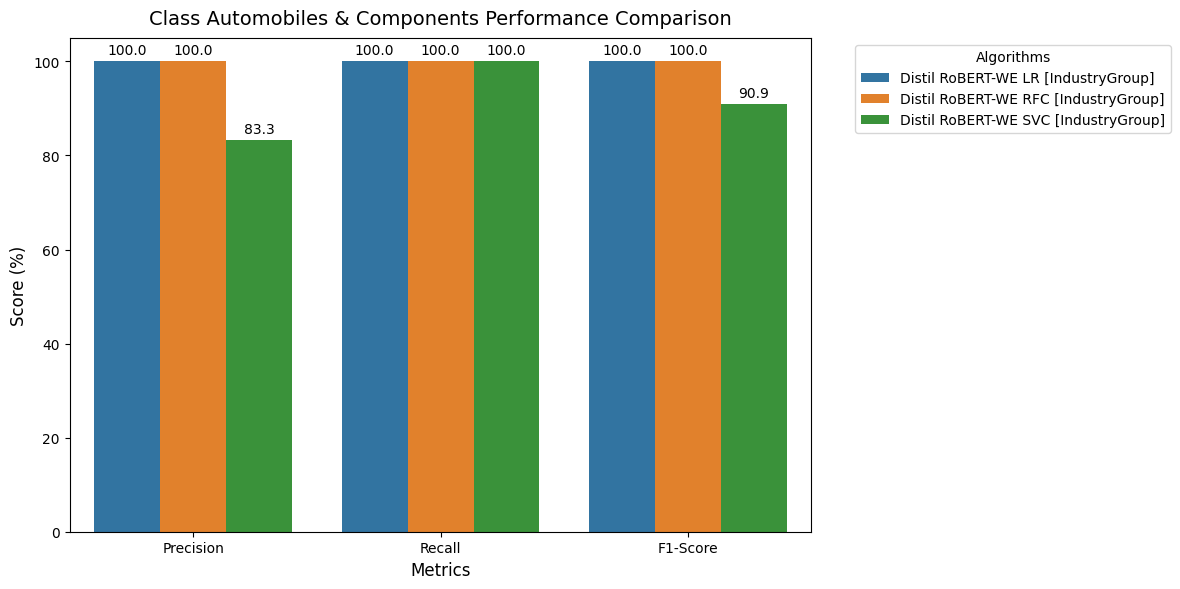

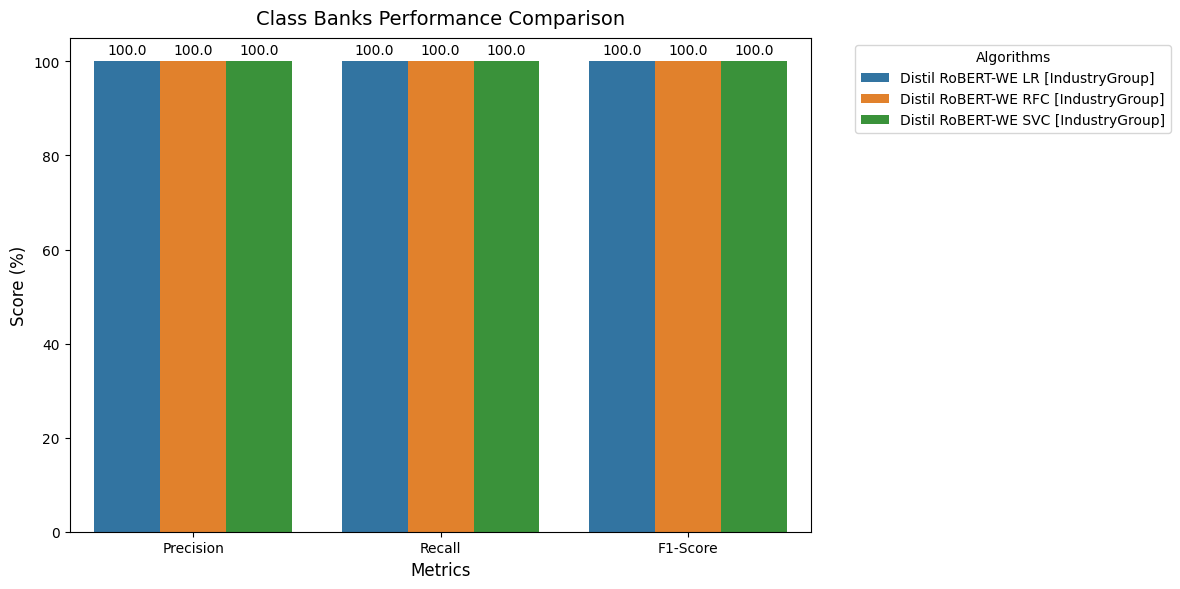

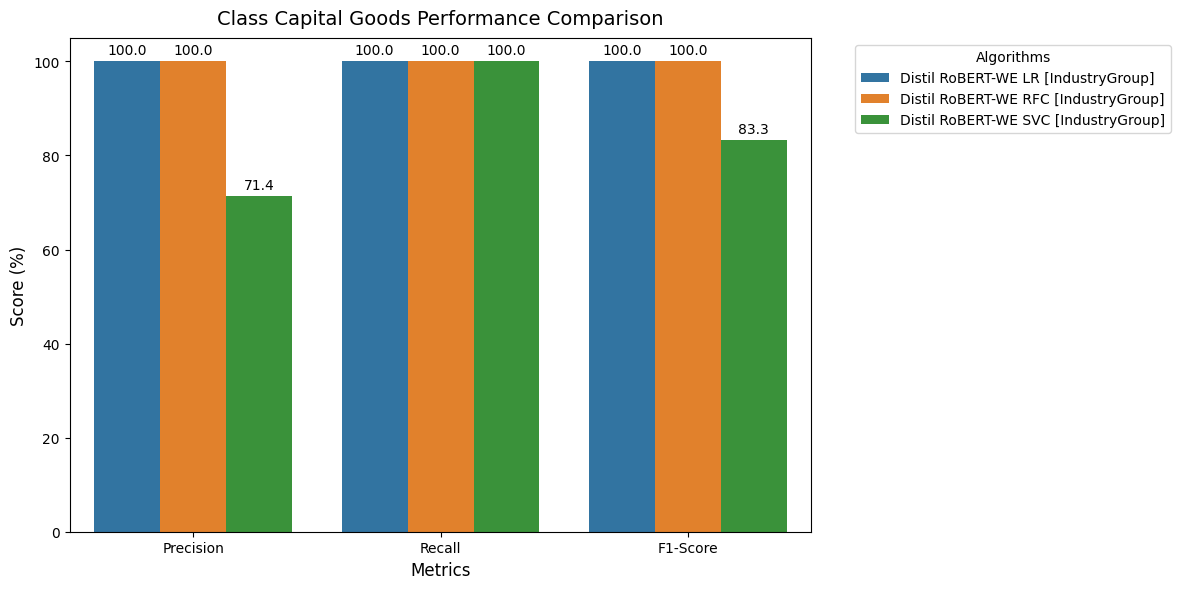

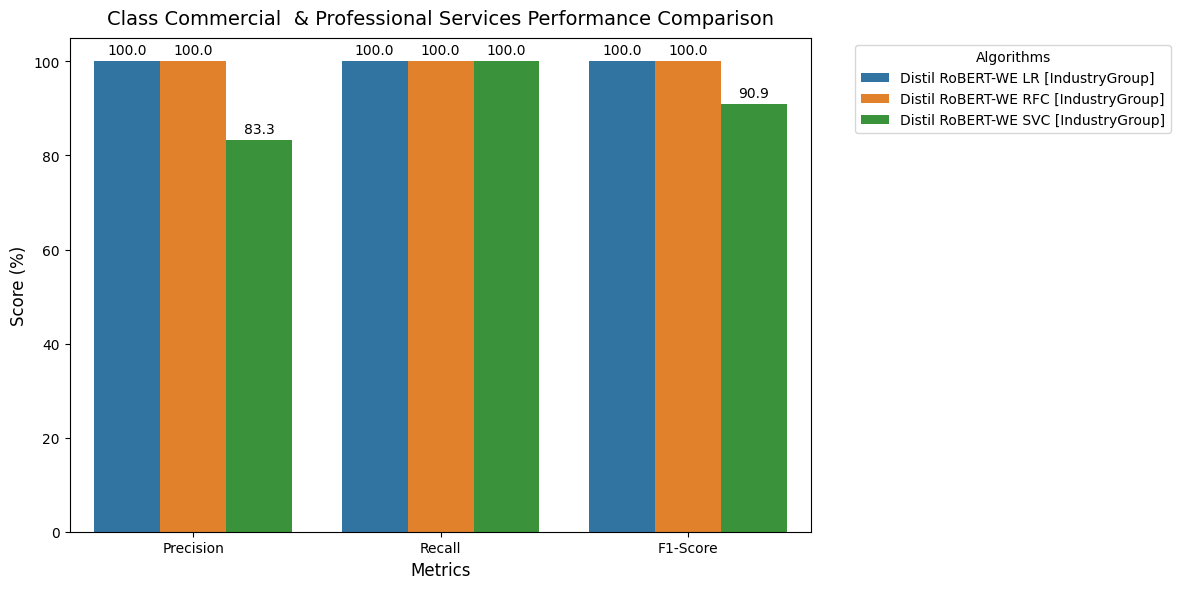

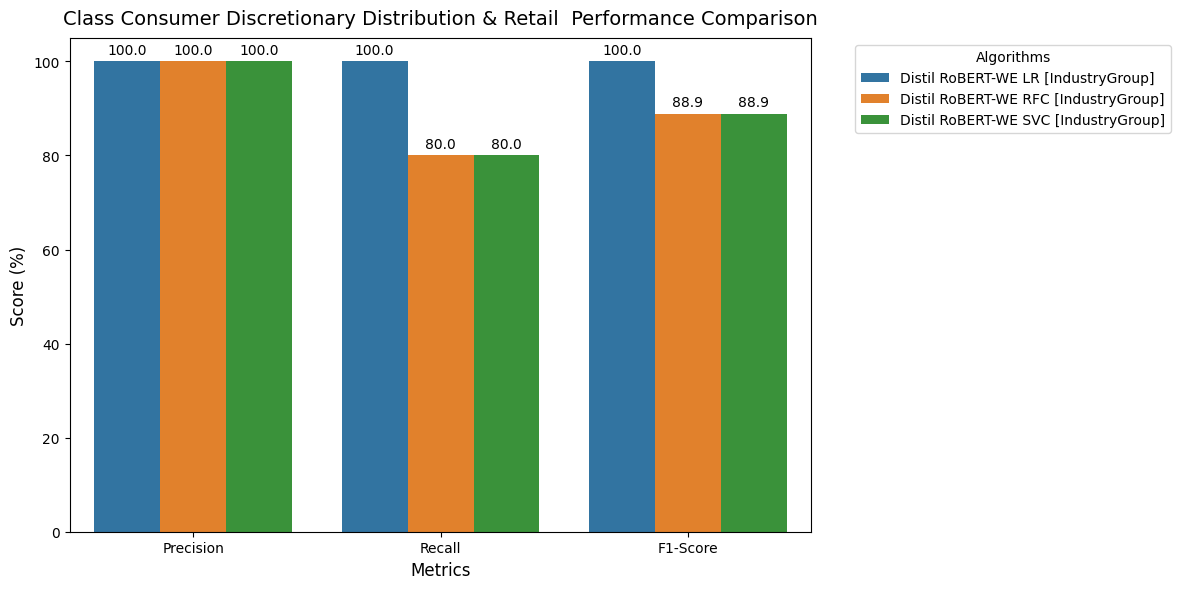

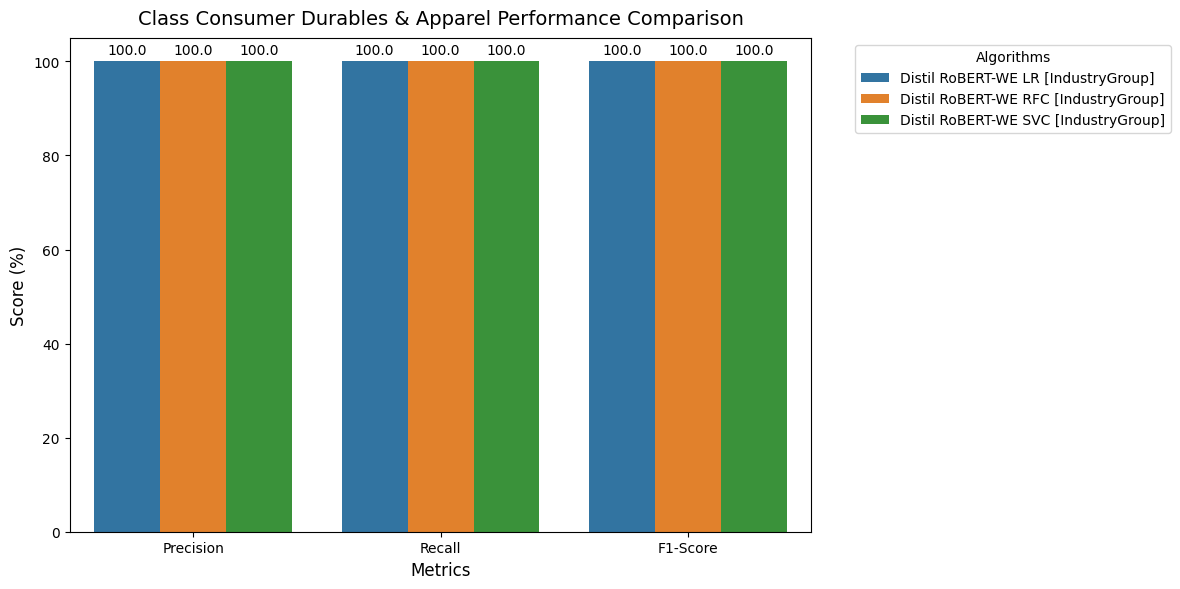

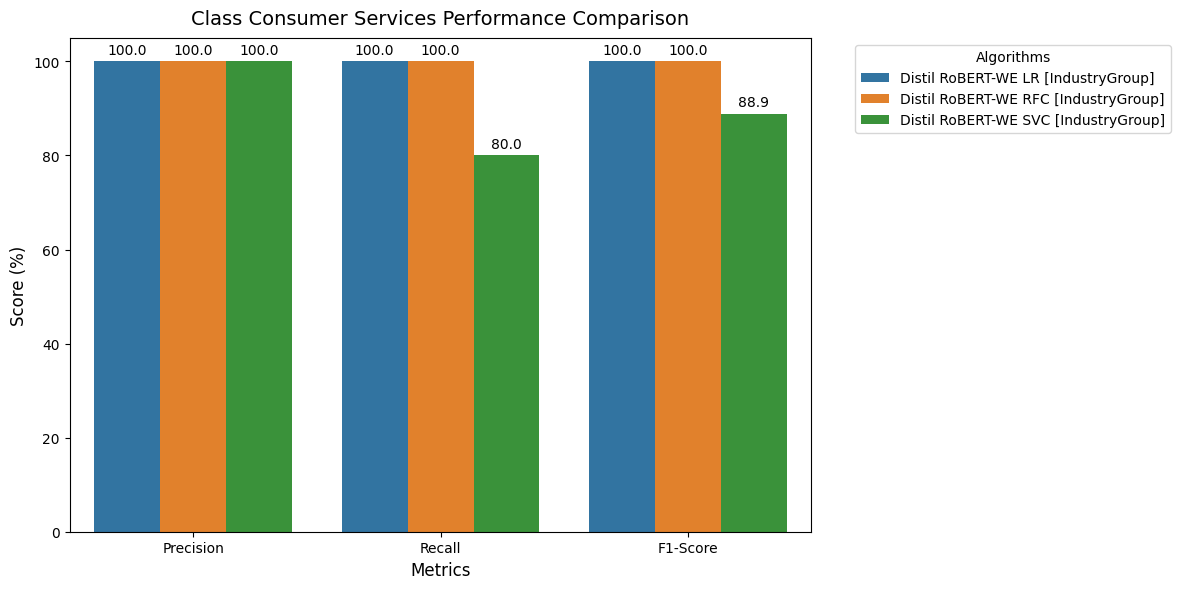

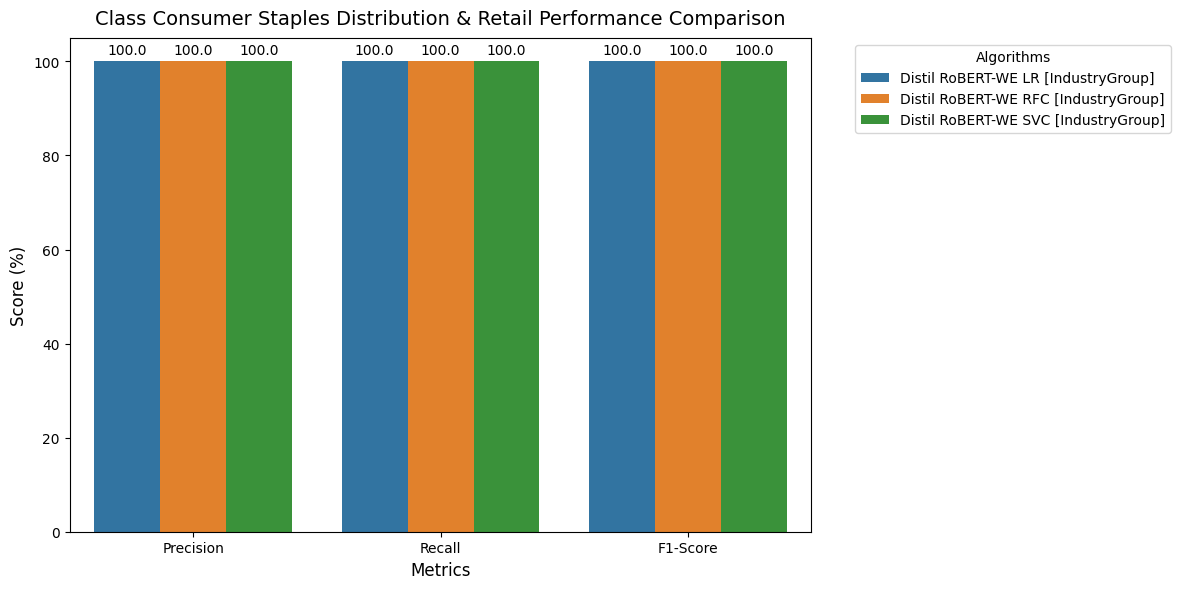

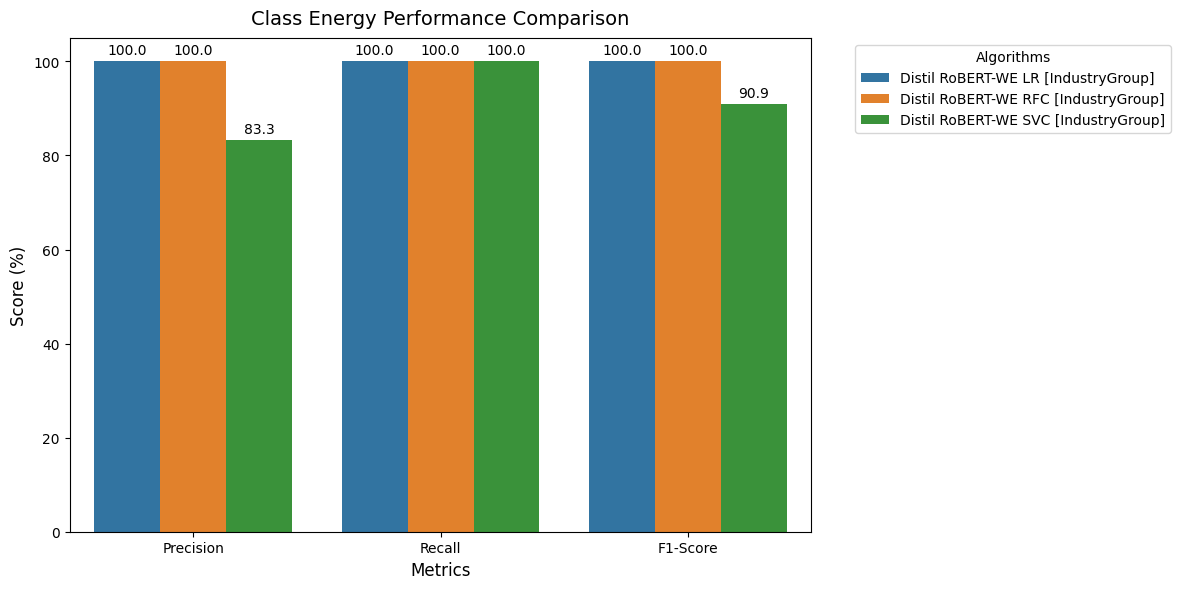

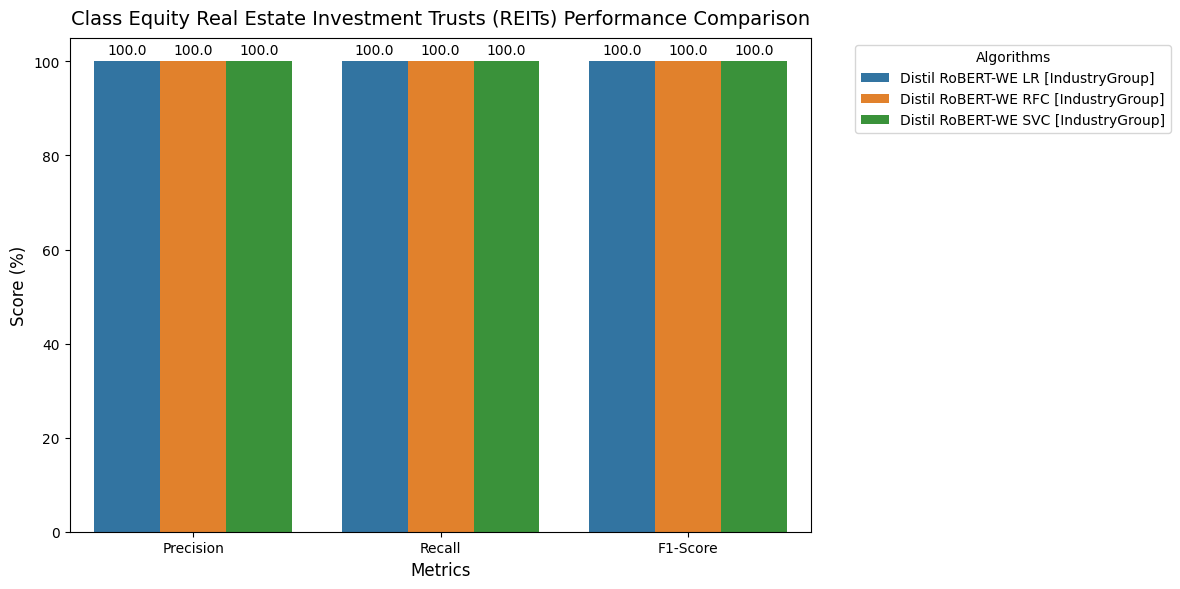

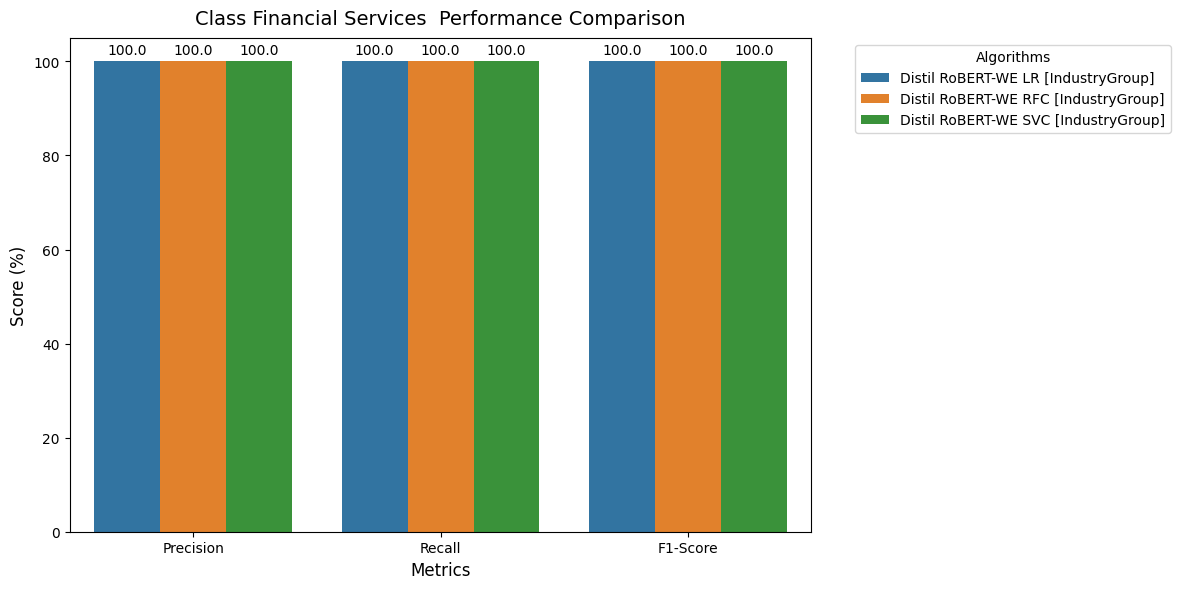

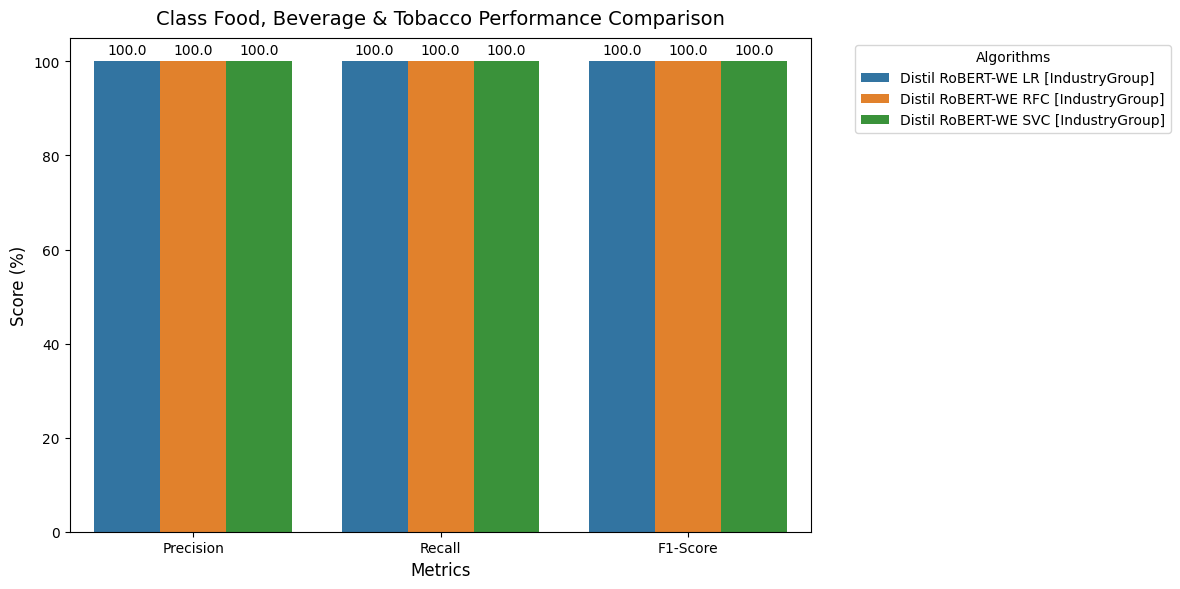

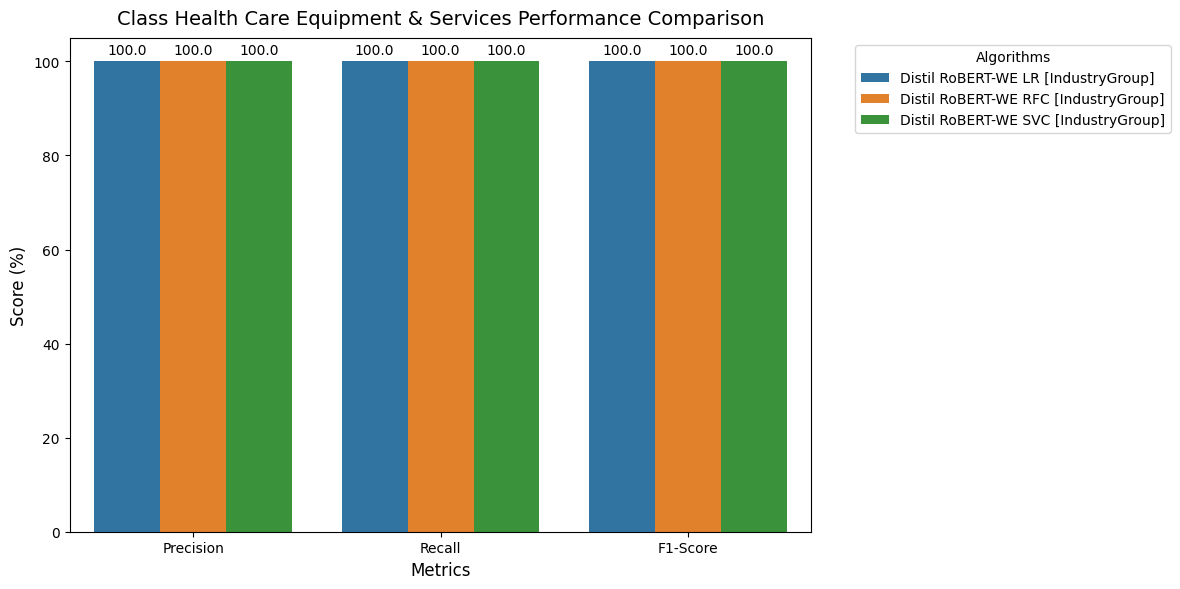

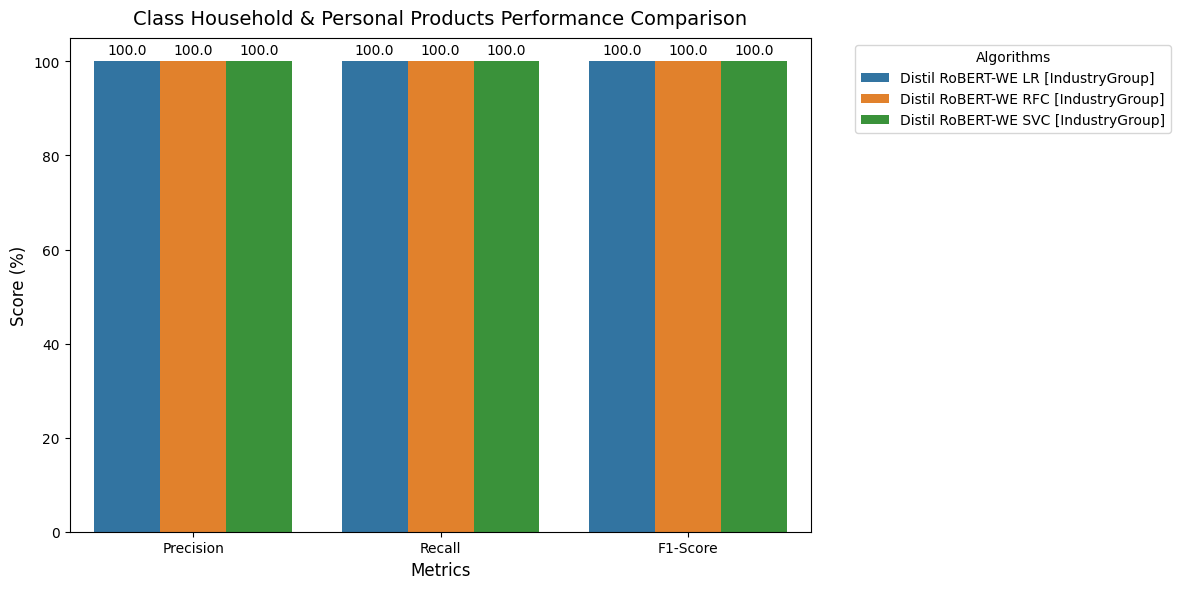

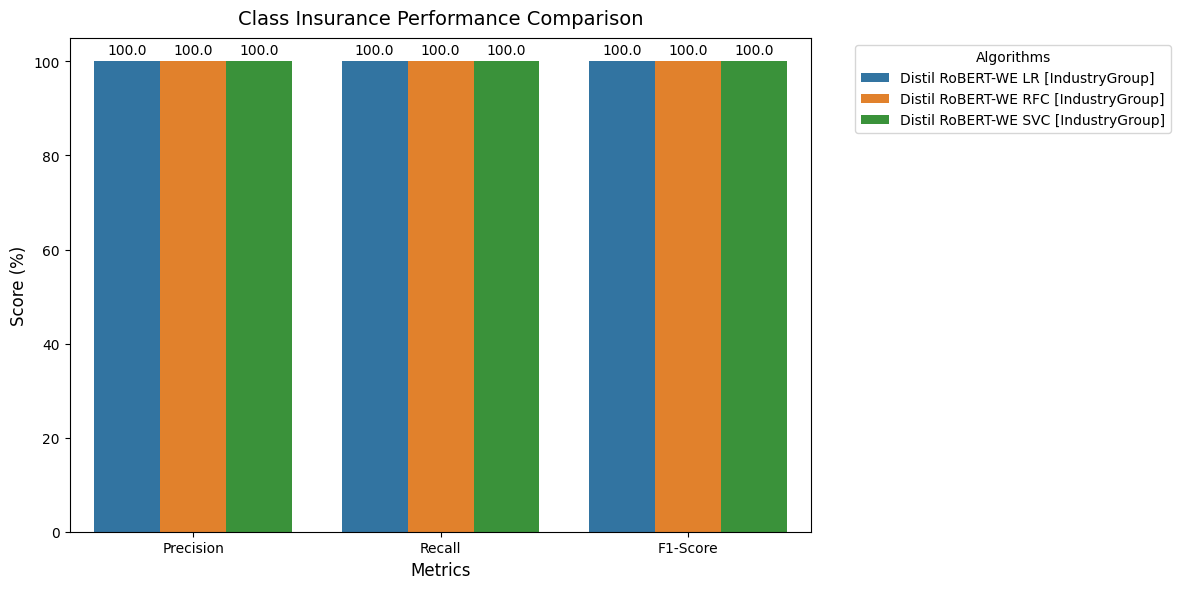

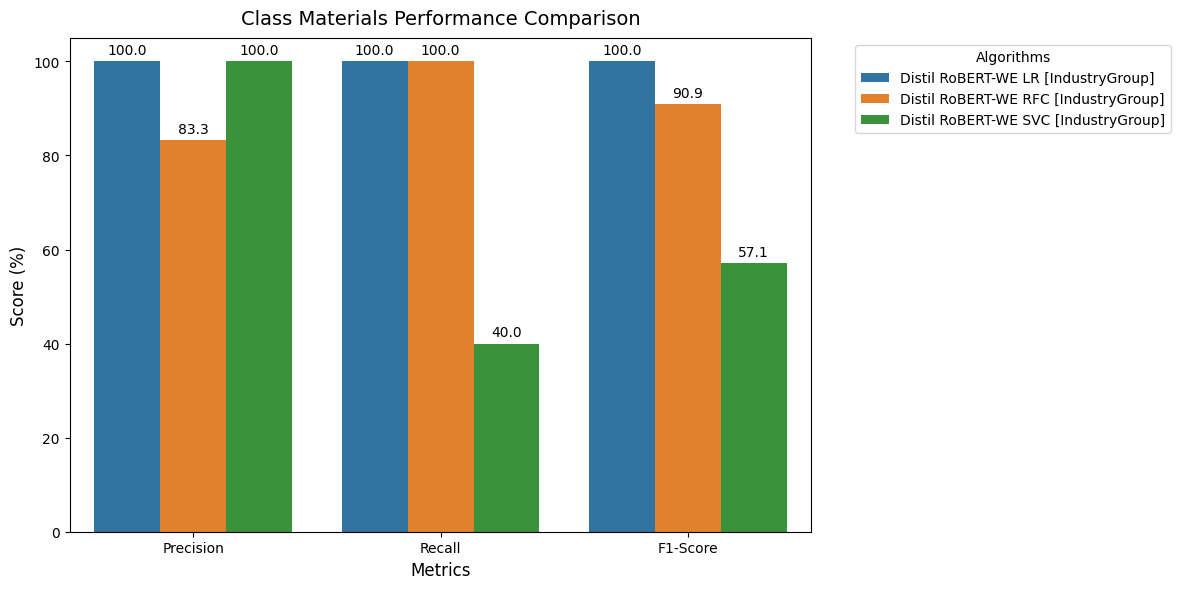

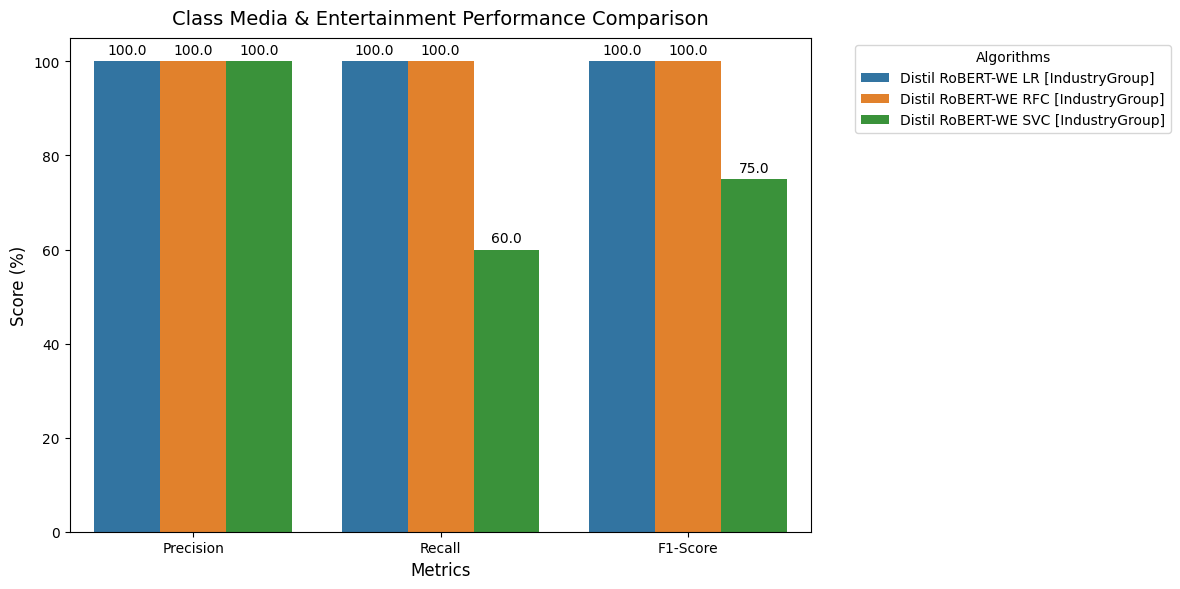

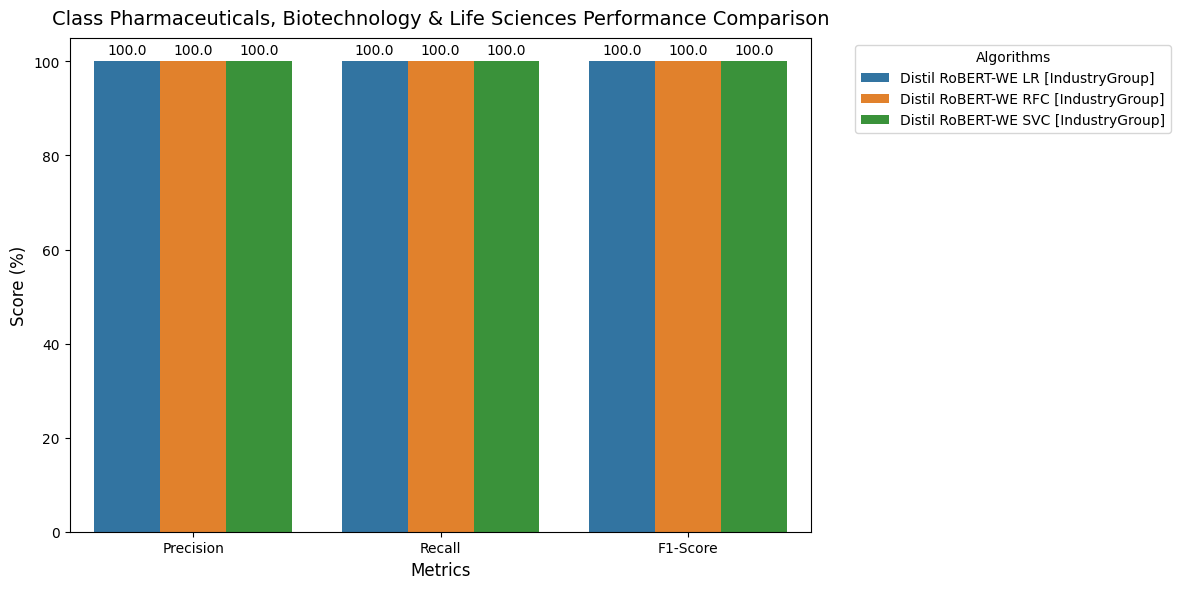

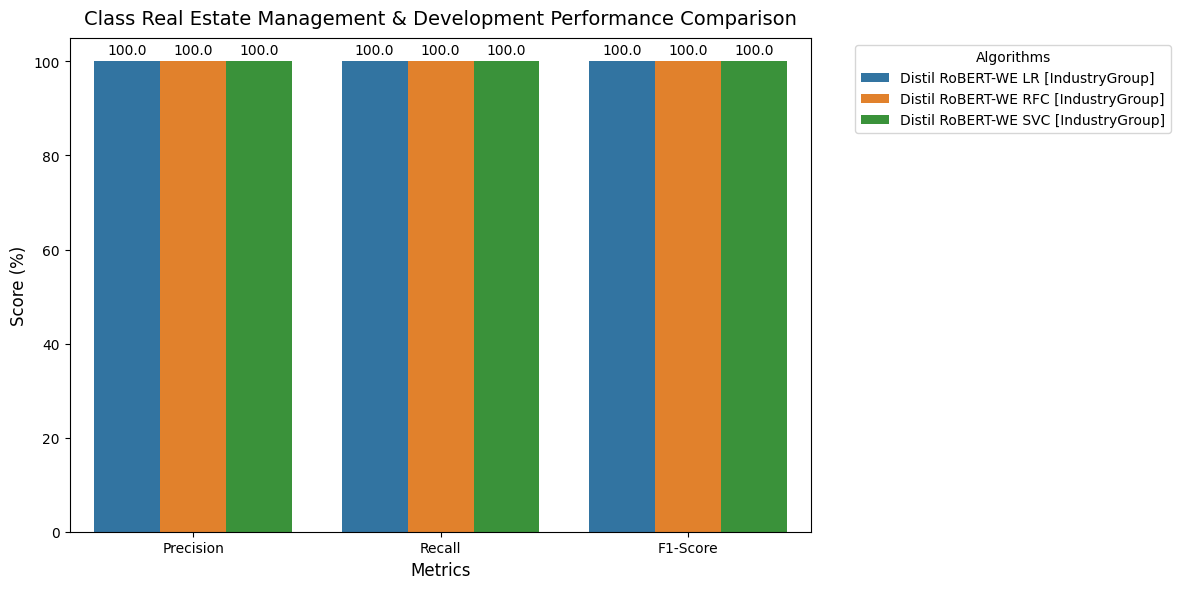

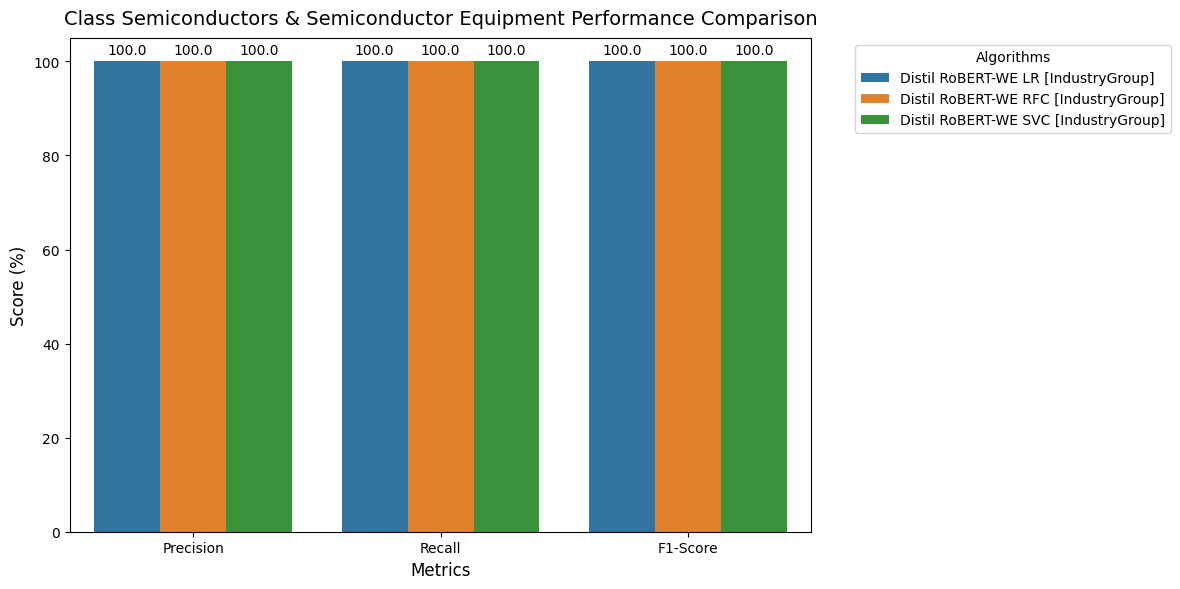

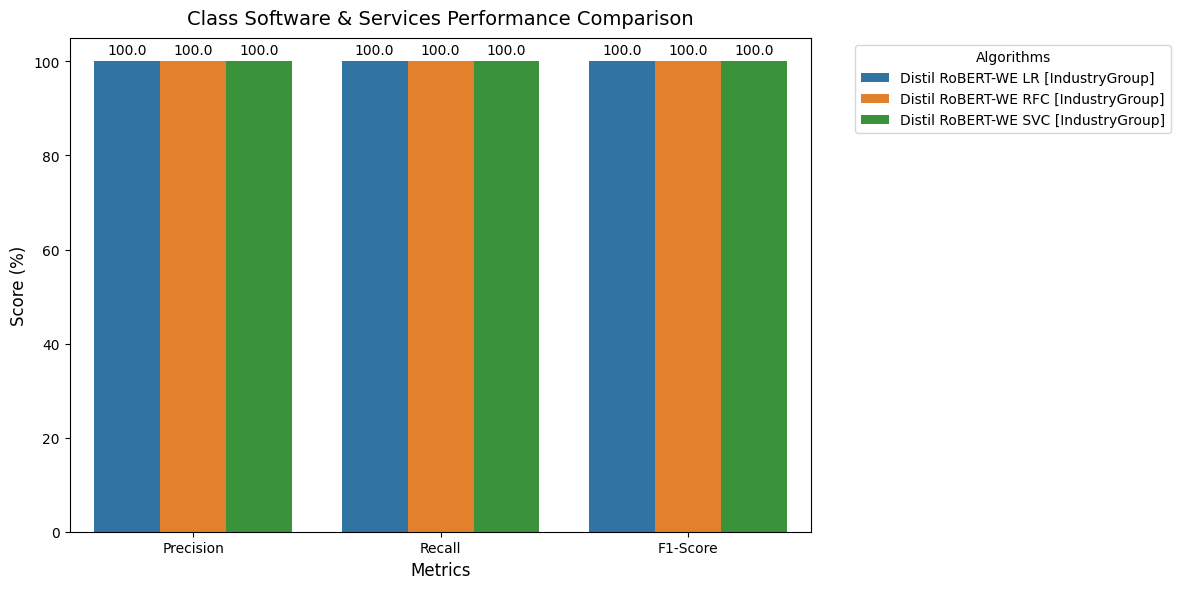

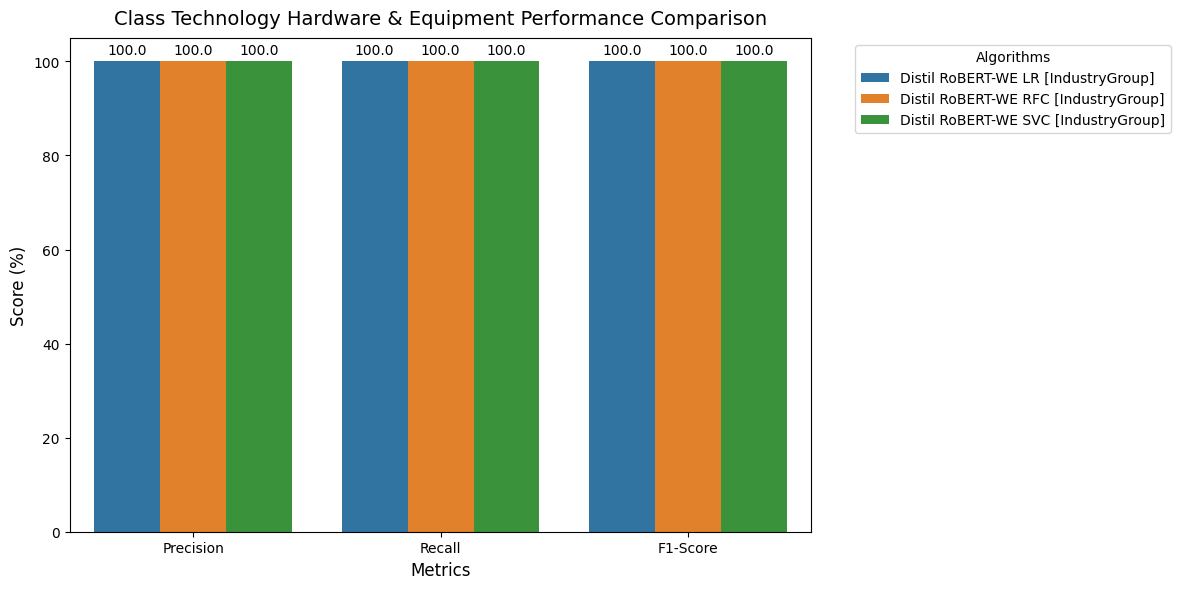

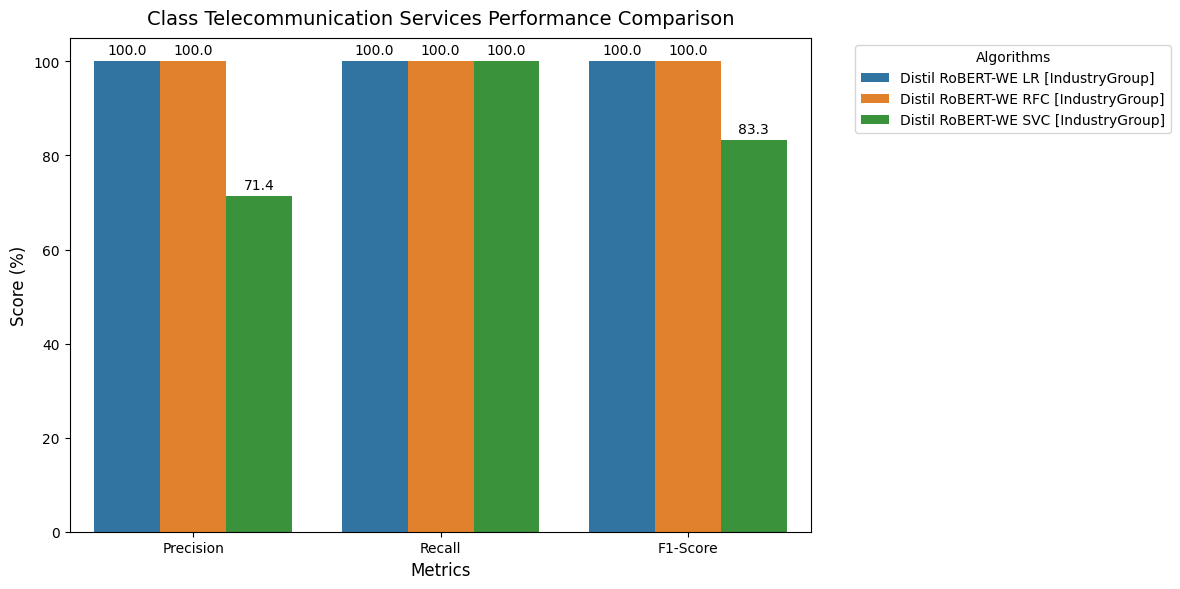

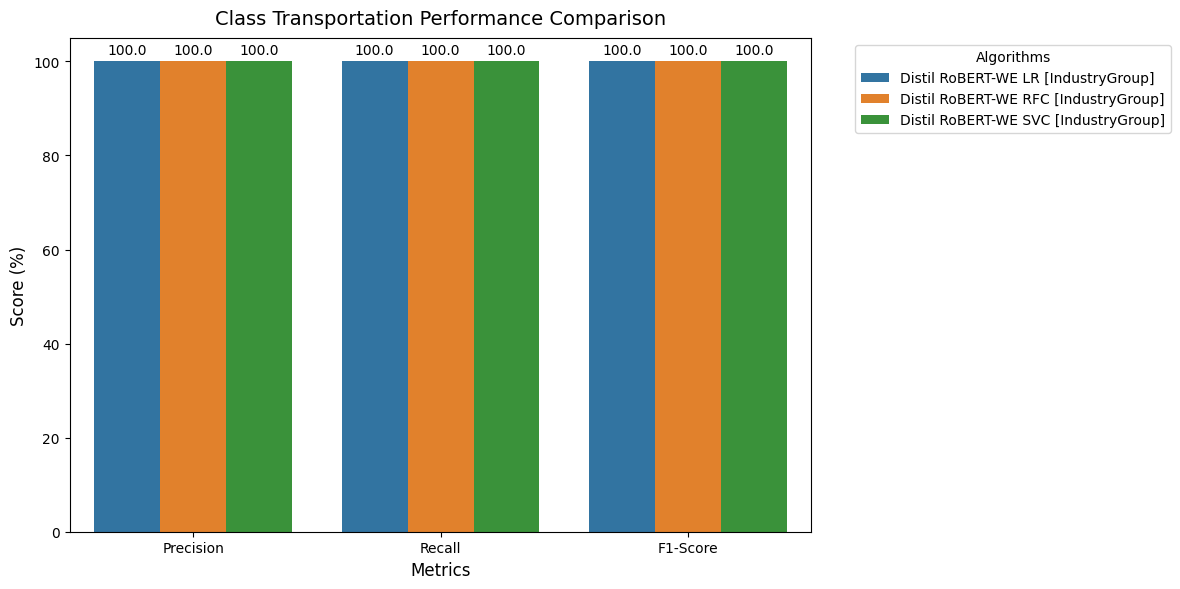

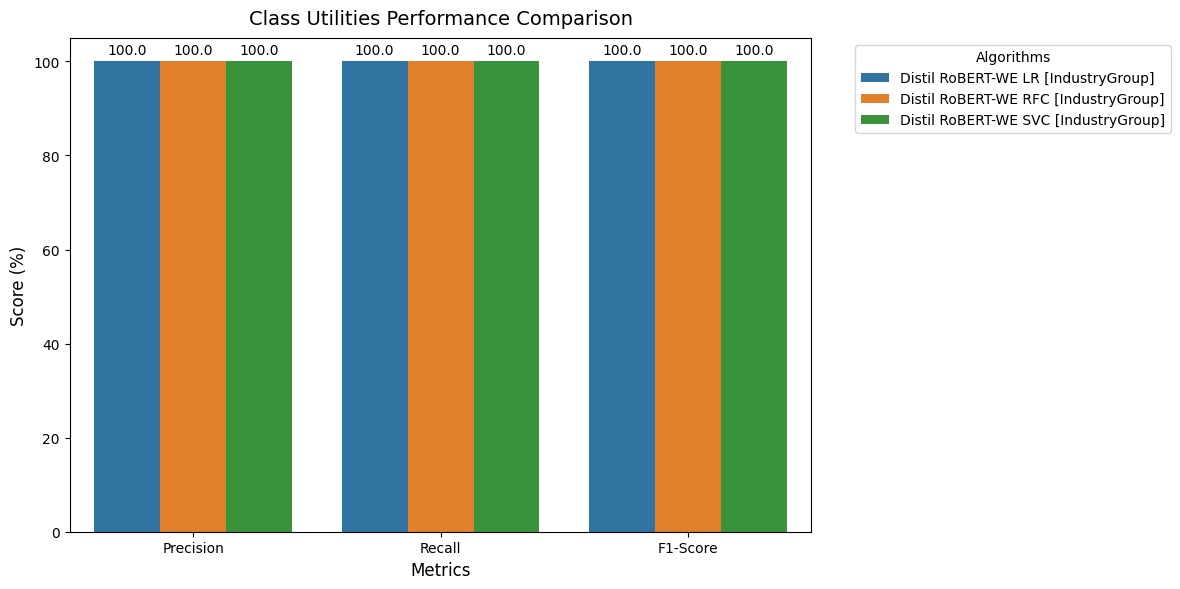

In [19]:
graph_plotter_lb1 = GraphPlotter(metrics_calculator_lb1.metrics_df, metrics_calculator_lb1.class_performance_dfs)
graph_plotter_lb1.plot_all()

In [20]:
melted_df_lb1 = metrics_calculator_lb1.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_lb1 = melted_df_lb1.round(3)
melted_df_lb1

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Distil RoBERT-WE LR [IndustryGroup],100.0,100.000,100.0,100.000
1,Distil RoBERT-WE RFC [IndustryGroup],99.2,99.333,99.2,99.192
2,Distil RoBERT-WE SVC [IndustryGroup],94.4,95.714,94.4,93.973


In [21]:
test_path=r"Dataset/Test_Less.csv"

In [22]:
df_test1= upload_dataset(test_path)
df_test1
# Initialize result DataFrame
df_result = df_test1.copy()


In [23]:
df_test,_ = preprocess_data(df_test1)

Preprocessing data (no saving)


In [24]:
features_test = feature_extraction(df_test,method='Distil RoBERT with Word Embeddings',is_train=None)

[INFO] Feature extraction method: Distil RoBERT with Word Embeddings, Train mode: None
[INFO] Performing RoBERTa feature extraction for testing...


Extracting RoBERTa embeddings: 100%|█████████████████████████████████████████████████████| 2/2 [00:08<00:00,  4.23s/it]


In [25]:
model_path = f"model/Distil RoBERT-WE_IndustryGroup_LR_model.pkl"
model = joblib.load(model_path)
y_pred = model.predict(features_test)
mapped_labels = [labels1[i] for i in y_pred]
df_result[f'Predicted_IndustryGroup'] = mapped_labels

In [26]:
df_result

,SectorId,Sector,IndustryGroupId,IndustryId,Industry,SubIndustryId,SubIndustry,SubIndustryDescription,Predicted_IndustryGroup
0,10,Energy,1010,101010,Energy Equipment & Services,10101010,Oil & Gas Drilling,Drilling contractors or owners of drilling rig...,Energy
1,10,Energy,1010,101010,Energy Equipment & Services,10101020,Oil & Gas Equipment & Services,"Manufacturers of equipment, including drilling...",Energy
2,10,Energy,1010,101020,"Oil, Gas & Consumable Fuels",10102010,Integrated Oil & Gas,Integrated oil companies engaged in the explor...,Energy
3,10,Energy,1010,101020,"Oil, Gas & Consumable Fuels",10102020,Oil & Gas Exploration & Production,Companies engaged in the exploration and produ...,Energy
4,10,Energy,1010,101020,"Oil, Gas & Consumable Fuels",10102030,Oil & Gas Refining & Marketing,Companies engaged in the refining and marketin...,Energy
5,10,Energy,1010,101020,"Oil, Gas & Consumable Fuels",10102040,Oil & Gas Storage & Transportation,Companies engaged in the storage and/or transp...,Energy
6,10,Energy,1010,101020,"Oil, Gas & Consumable Fuels",10102050,Coal & Consumable Fuels,Companies primarily involved in the production...,Energy
7,15,Materials,1510,151010,Chemicals,15101010,Commodity Chemicals,Companies that primarily produce industrial ch...,Materials
8,15,Materials,1510,151010,Chemicals,15101020,Diversified Chemicals,Manufacturers of a diversified range of chemic...,Materials
9,15,Materials,1510,151010,Chemicals,15101030,Fertilizers & Agricultural Chemicals,"Producers of fertilizers, pesticides, potash o...",Materials
